In [9]:
import numpy as np
import matplotlib.pyplot as plt

sig=5:
-0.5 2.223360819420306 1.78


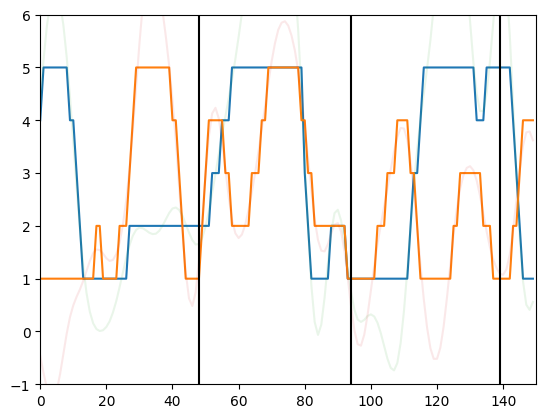

sig=6:
0.44666666666666666 1.6063900176759343 1.3666666666666667


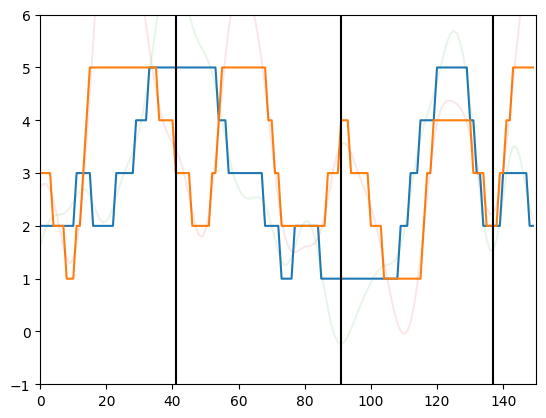

sig=7:
-0.9266666666666666 1.8514738873544925 1.5933333333333333


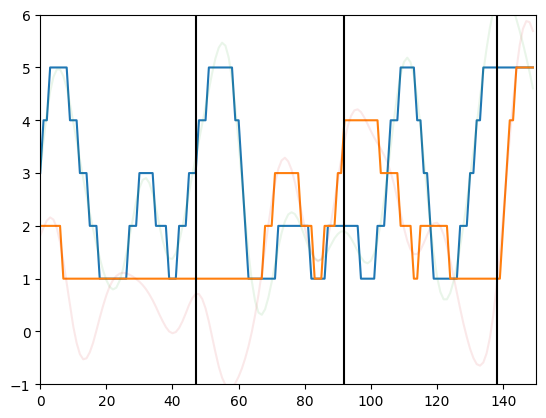

sig=8:
-0.44666666666666666 2.1370904415947294 1.86


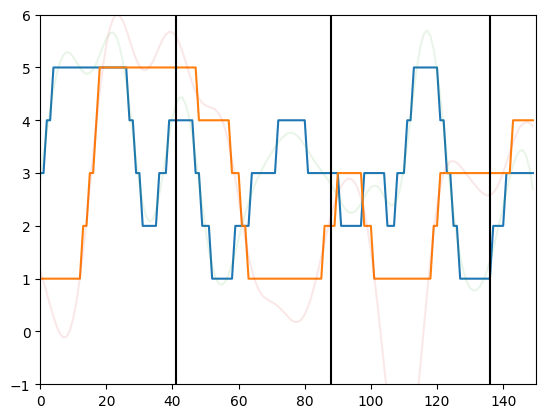

sig=9:
-0.06 1.4570746949510403 0.9


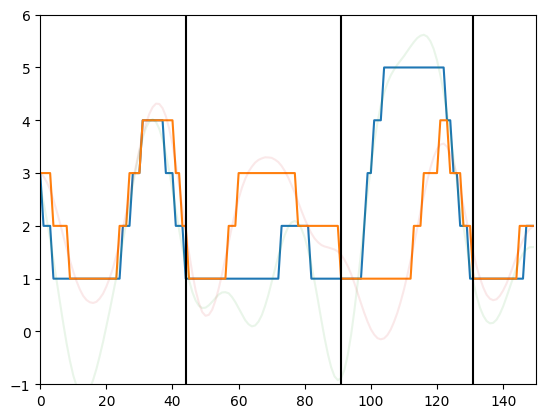

sig=10:
0.9866666666666667 2.1353740239644723 2.0


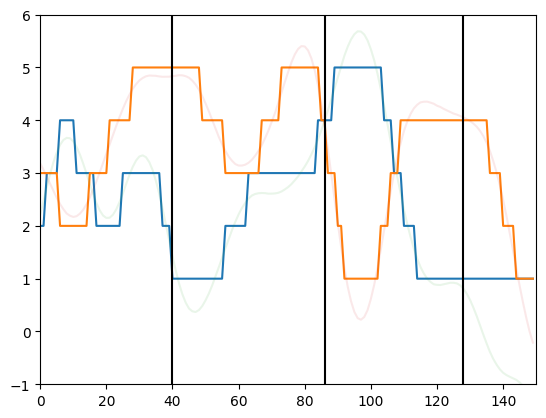

sig=11:
-0.34 1.9793264847753977 1.6866666666666668


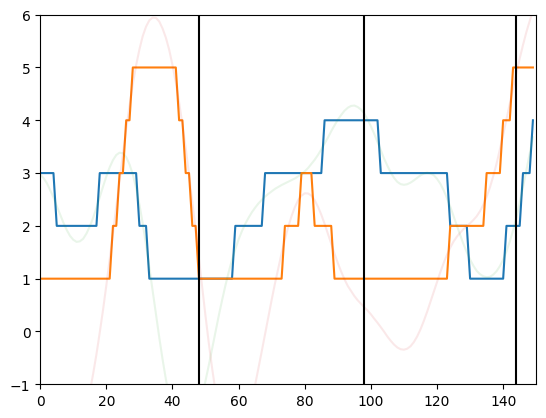

sig=12:
-0.2866666666666667 2.105031010592375 1.6733333333333333


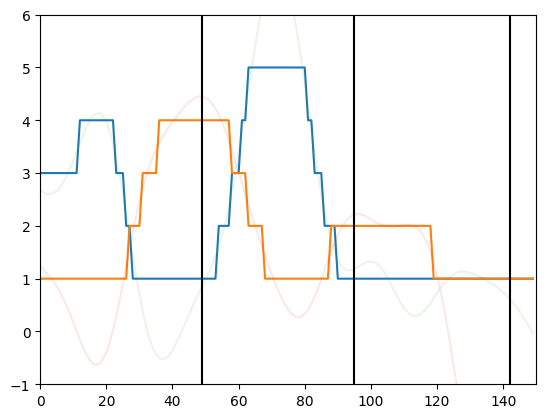

sig=13:
1.2733333333333334 1.9795510153118618 1.9666666666666666


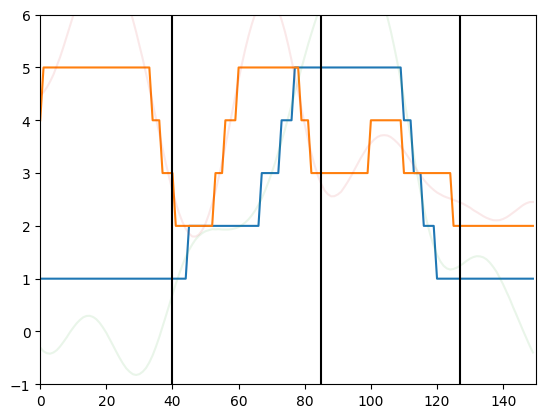

sig=14:
-0.28 2.0103730997006504 1.72


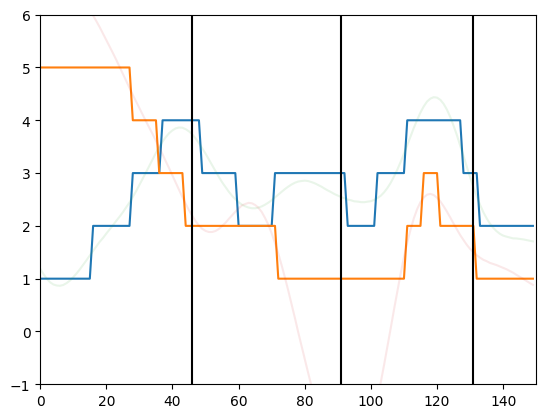

sig=15:
0.3333333333333333 2.168460795638746 1.8133333333333332


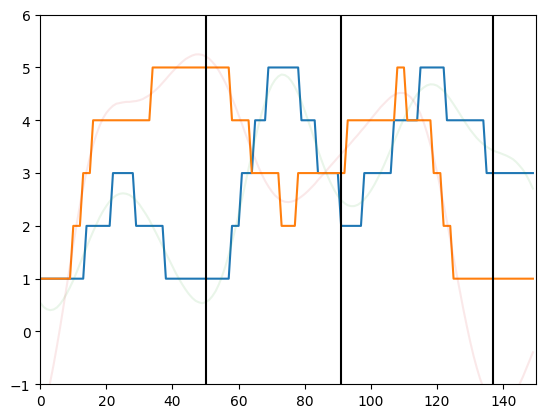

sig=16:
0.44 1.3975216158137471 1.0666666666666667


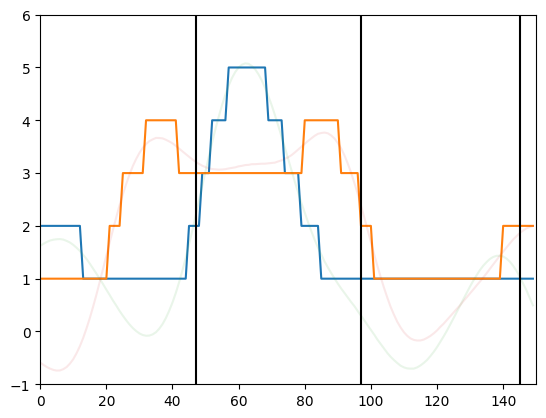

sig=17:
-2.34 1.0883014288330233 2.34


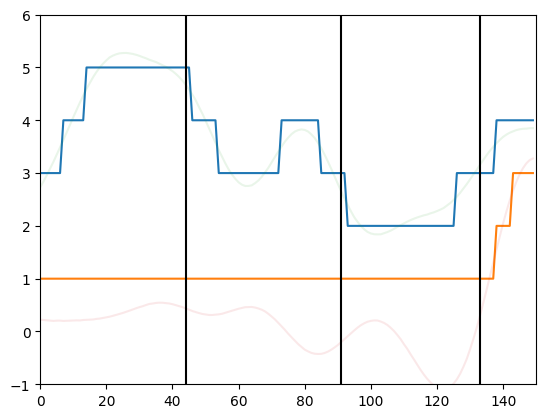

sig=18:
0.10666666666666667 1.9600907008492123 1.5866666666666667


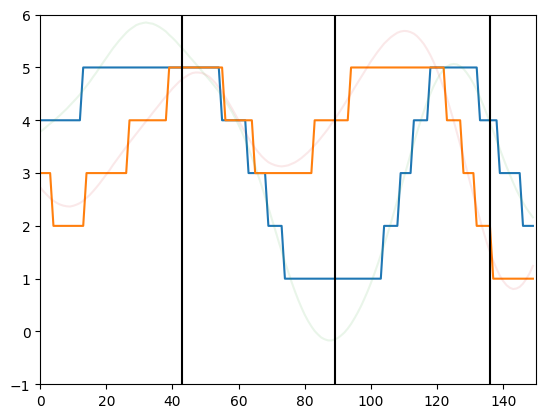

sig=19:
1.06 1.58 1.5533333333333332


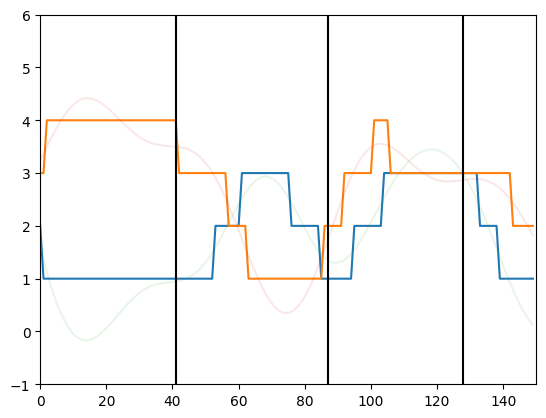

sig=20:
-0.7666666666666667 2.598503843026256 2.22


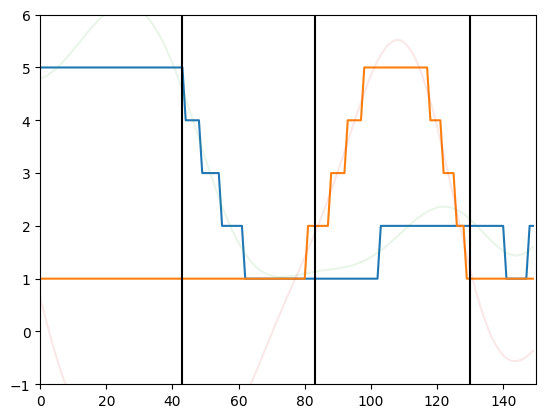

sig=21:
-0.6466666666666666 1.9904326721148402 1.8866666666666667


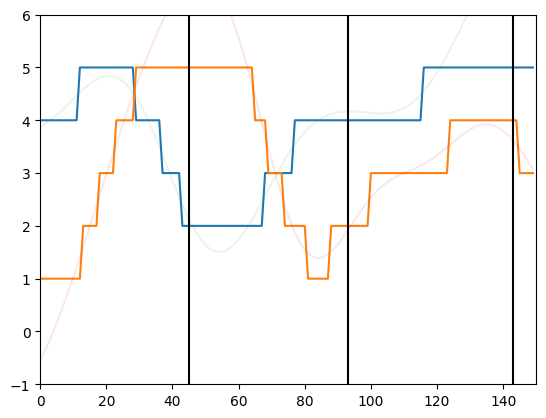

sig=22:
1.3133333333333332 1.2336215879361963 1.38


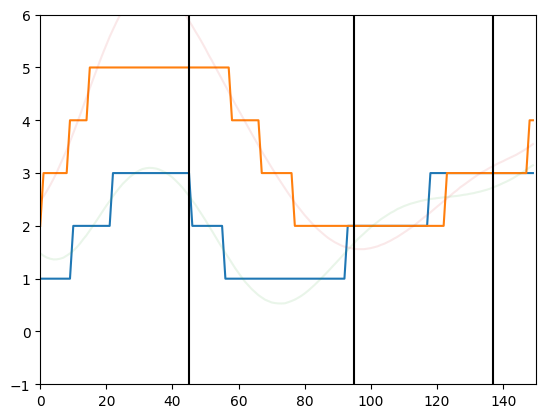

sig=23:
0.5 2.055075018906447 1.66


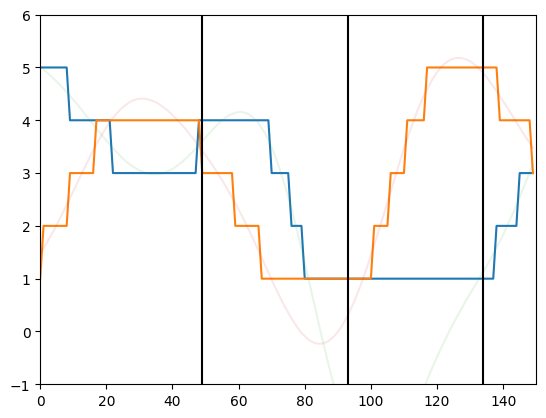

sig=24:
-1.3466666666666667 1.49214238224403 1.6933333333333334


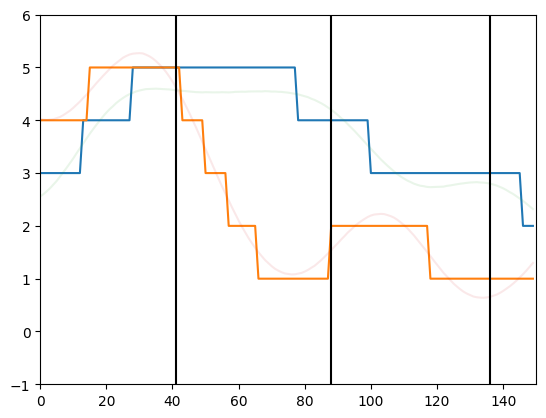

sig=25:
-0.2733333333333333 1.2904607273717743 1.06


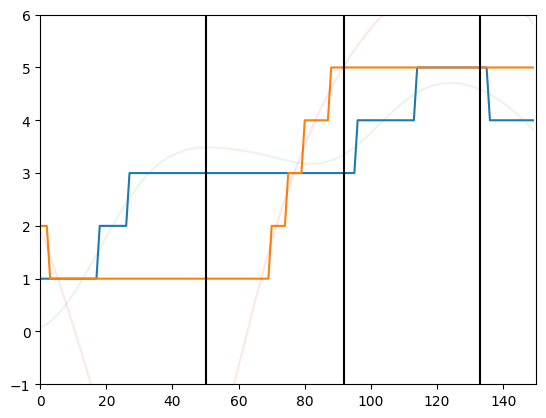

sig=26:
-1.2866666666666666 1.5549347967751646 1.4866666666666666


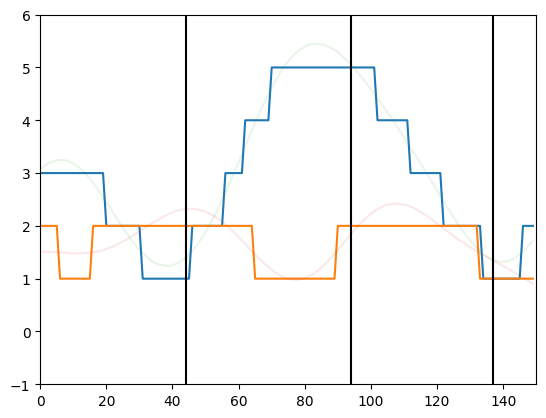

sig=27:
-1.38 1.398427688513067 1.7666666666666666


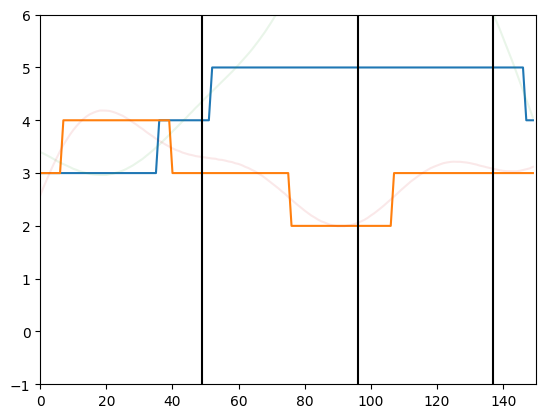

sig=28:
-0.7066666666666667 1.714824254033696 1.36


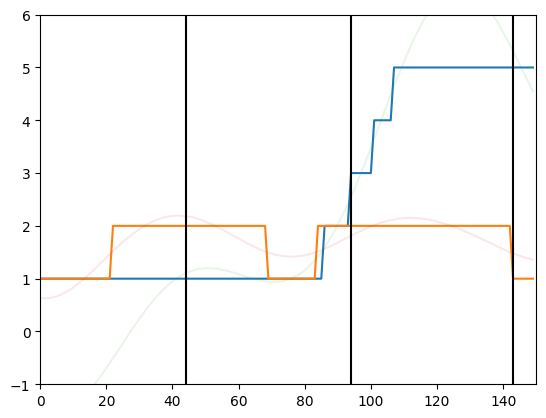

sig=29:
1.9933333333333334 1.2247267268887194 1.9933333333333334


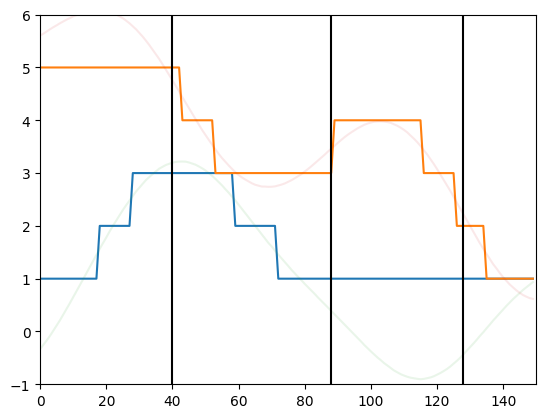

In [13]:
for sig in range(5, 30, 1):
  T = 150
  block_lengths = range(40,51)

  xs = np.random.normal(0, 1, (T, 2))
  ts = np.arange(T)
  K = np.exp(-(ts[:, None] - ts[None, :])**2 / (2*sig**2)) + np.eye(T)*1e-6
  L = np.linalg.cholesky(K)
  blocks = np.random.choice(block_lengths, 5)
  blocks = np.cumsum(blocks)
  vals = 2.0*L @ xs + 2.5
  ivals = np.clip(np.round(vals), 1, 5)

  diffs = ivals[:, 1] - ivals[:, 0]
  print(f"sig={sig}:")
  print(np.mean(diffs), np.std(diffs), np.mean(np.abs(diffs)))

  plt.figure()
  plt.plot(ivals)
  plt.plot(vals, alpha = 0.1)
  for b in blocks:
    plt.axvline(b, color = "k")
  plt.xlim(0, T)
  plt.ylim(-1, 6)
  plt.show()

0.08666666666666667 1.2854916914896375 0.9666666666666667


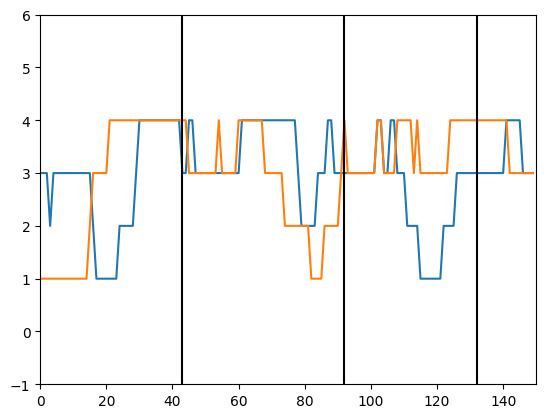

In [2]:
T = 150

pud = 0.10
pstay = 1-2*pud
val_list = range(1, 5)
ps = np.array([[pstay+pud, pud, 0, 0],
              [pud, pstay, pud, 0],
              [0, pud, pstay, pud],
              [0, 0, pud, pstay+pud]])
vals = np.zeros((T, 2), dtype = int)
vals[0] = np.random.choice(val_list, 2, replace = True)
for t in range(T-1):
  vals[t+1] = np.array([np.random.choice(val_list, p = ps[vals[t, i]-1])for i in range(2)])

diffs = vals[:, 1] - vals[:, 0]
print(np.mean(diffs), np.std(diffs), np.mean(np.abs(diffs)))

plt.figure()
plt.plot(vals, alpha = 1.0)
for b in blocks:
  plt.axvline(b, color = "k")
plt.xlim(0, T)
plt.ylim(-1, 6)
plt.show()
